### [Time Series Momentum Strategy with Linear Regression](https://wire.insiderfinance.io/machine-learning-for-quants-series-with-python-part-1-8e7980bf7458)

> Machine Learning for Quants (Part 1)

In [1]:
!pip install -qq --no-deps tensorflow scikit-learn numpy pandas matplotlib yfinance imbalanced-learn

In [2]:
import sys
import time

IN_COLAB = 'google.colab' in sys.modules

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, Adam

from imblearn.over_sampling import SMOTE

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

tf.random.set_seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('fivethirtyeight') # seaborn-v0_8-whitegrid
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

%autosave 10

Autosaving every 10 seconds


In [3]:
def plot_classification_report(y_true, y_pred, y_prob=None):
  report_dict = classification_report(y_true, y_pred, output_dict=True)
  df_report = pd.DataFrame(report_dict).iloc[:-1, :].T

  plt.figure(figsize=(12, 8))
  sns.heatmap(df_report, annot=True, cmap='Blues')
  plt.title('Classification Report')
  plt.show()

#### **Setup and Data Acquisition**

In [4]:
# Download historical data for SPY
# We use a long window to ensure enough data points
df = yf.download('SPY', start='2013-01-01', end='2026-01-01', progress=False, multi_level_index=False)

# Calculate daily returns
df['Return'] = df['Close'].pct_change()

# Drop NaN values created by pct_change
df.dropna(inplace=True)

print(f"Data Loaded: {len(df)} days of trading data.")
display(df.head())

Data Loaded: 3269 days of trading data.


,Close,High,Low,Open,Volume,Return
Date,,,,,,
2013-01-03,116.0290,116.5385,115.7184,116.2360,144761800,-0.0023
2013-01-04,116.5385,116.7296,115.9811,116.2200,116817700,0.0044
2013-01-07,116.2201,116.3316,115.7902,116.1246,110002500,-0.0027
2013-01-08,115.8857,116.1723,115.4318,116.0130,121265100,-0.0029
2013-01-09,116.1803,116.4987,115.9573,116.1404,90745600,0.0025


#### **Feature Engineering (The Momentum Signal)**

In [5]:
# Create lag features (signals)
# We want to use the returns of the past 5 days to predict today's return
lags = 5

for i in range(1, lags + 1):
  df[f'Lag_{i}'] = df['Return'].shift(i)

# Drop the NaN values created by shifting
df.dropna(inplace=True)

# Define Features (X) and Target (y)
feature_cols = [f'Lag_{i}' for i in range(1, lags + 1)]
X = df[feature_cols]
y = df['Return']

print("Feature Matrix X (First 5 rows):")
display(X.head())

Feature Matrix X (First 5 rows):


,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
Date,,,,,
2013-01-10,0.0025,-0.0029,-0.0027,0.0044,-0.0023
2013-01-11,0.0079,0.0025,-0.0029,-0.0027,0.0044
2013-01-14,-0.0001,0.0079,0.0025,-0.0029,-0.0027
2013-01-15,-0.0007,-0.0001,0.0079,0.0025,-0.0029
2013-01-16,0.0007,-0.0007,-0.0001,0.0079,0.0025


#### **Splitting the Dataset**

In [6]:
# Split into Training (80%) and Testing (20%) sets
# shuffle=False is CRITICAL for time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 2611
Testing set size: 653


#### **Training the Linear Regression Model**

In [7]:
# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# View learned coefficients (The "Theta" values)
print("Intercept (Bias):", lr_model.intercept_)
print("Coefficients (Weights):", lr_model.coef_)
print("Score: ", lr_model.score(X_train, y_train))

Intercept (Bias): 0.0005926977437954656
Coefficients (Weights): [-0.1187  0.0535 -0.0077 -0.0684  0.0222]
Score:  0.023887391754142673


#### **Evaluation and Visualizing Performance**

Mean Squared Error (Linear Model): 0.00009265


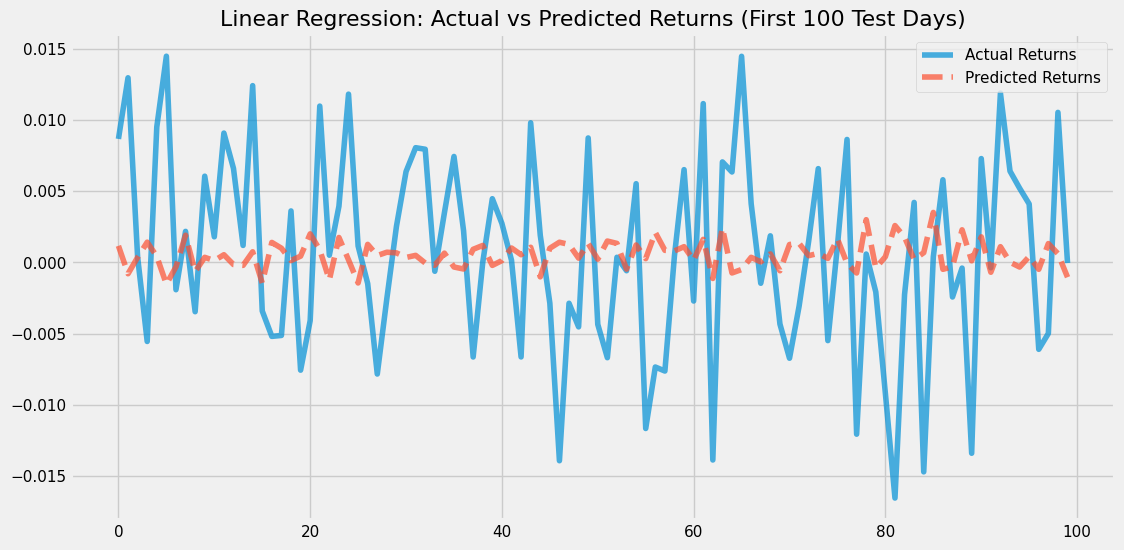

In [8]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (Linear Model): {mse:.8f}")

# Visualization: Predicted vs Actual (Subset for clarity)
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Returns', alpha=0.7)
plt.plot(y_pred[:100], label='Predicted Returns', alpha=0.7, linestyle='--')
plt.title('Linear Regression: Actual vs Predicted Returns (First 100 Test Days)')
plt.legend()
plt.show()

#### **Forcing Overfitting (Polynomial Features)**

In [9]:
# Create polynomial features (degree 4 - highly complex)
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a new model on this complex data
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict on Train and Test
y_train_pred_poly = poly_model.predict(X_train_poly)
y_test_pred_poly = poly_model.predict(X_test_poly)

# Calculate Errors
train_mse = mean_squared_error(y_train, y_train_pred_poly)
test_mse = mean_squared_error(y_test, y_test_pred_poly)

print(f"Training MSE (Poly Model): {train_mse:.8f}")
print(f"Testing MSE (Poly Model):  {test_mse:.8f}")

Training MSE (Poly Model): 0.00008087
Testing MSE (Poly Model):  0.00112168


### [Master Regularization: Ridge, Lasso & ElasticNet](https://medium.com/@simplifiedzone/master-regularization-ridge-lasso-elasticnet-explained-3290d06c9700)

> Machine Learning for Quants (Part 2)

#### **Data Preparation (Recap)**

In [10]:
# 1. Fetch Data
df = yf.download('SPY', start='2010-01-01', end='2026-01-01', multi_level_index=False, progress=False, interval='1d')
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

display(df.sample(10))

# 2. Engineer More Features (Lags 1 through 10)
# More features = higher risk of overfitting = better test for Regularization
lags = 10
feature_cols = []
for i in range(1, lags + 1):
    col_name = f'Lag_{i}'
    df[col_name] = df['Return'].shift(i)
    feature_cols.append(col_name)

df.dropna(inplace=True)

X = df[feature_cols]
y = df['Return']

# 3. Split Data (Chronological Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training Features: {X_train.shape[1]} inputs (Lags 1-10)")

,Close,High,Low,Open,Volume,Return
Date,,,,,,
2016-10-31,182.4363,182.9856,182.2732,182.7624,61272500,0.0000
2014-10-16,153.4111,154.4900,150.6274,150.7674,270391000,-0.0009
2020-10-27,313.5240,315.2853,313.3108,314.9516,65994100,-0.0034
2017-09-14,217.9198,218.1202,217.4928,217.6671,95446300,-0.0003
2014-11-17,168.3181,168.4911,167.7252,167.8899,80441000,0.0006
2011-11-07,97.7265,97.8272,96.1321,97.0532,196617200,0.0062
2024-03-15,497.7171,499.5427,496.0477,498.0880,107646300,-0.0069
2012-03-13,109.0954,109.1500,107.5610,107.7401,184090500,0.0180
2013-05-06,129.3808,129.5647,129.0929,129.1489,66882100,0.0025


Training Features: 10 inputs (Lags 1-10)


#### **Ridge Regression (Manual Tuning)**

In [11]:
# Initialize Ridge with a specific alpha (regularization strength)
# Alpha = 1.0 is a standard starting point
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge MSE (alpha=1.0): {mse_ridge:.8f}")
print("Ridge Coefficients:", ridge_model.coef_)

Ridge MSE (alpha=1.0): 0.00010103
Ridge Coefficients: [-0.0291  0.0176 -0.0074 -0.0123 -0.0034 -0.0214  0.0295 -0.0252  0.0212
 -0.0039]


#### **Lasso Regression (Feature Selection)**

In [12]:
# Initialize Lasso
# We assume a small alpha because returns are small numbers
lasso_model = Lasso(alpha=0.0001)
lasso_model.fit(X_train, y_train)

# Check Coefficients
print("\nLasso Coefficients:")
for feature, coef in zip(feature_cols, lasso_model.coef_):
    print(f"{feature}: {coef:.6f}")

# Count non-zero features
n_selected = np.sum(lasso_model.coef_ != 0)
print(f"\nLasso selected {n_selected} out of {lags} features.")


Lasso Coefficients:
Lag_1: -0.000000
Lag_2: 0.000000
Lag_3: -0.000000
Lag_4: -0.000000
Lag_5: -0.000000
Lag_6: -0.000000
Lag_7: 0.000000
Lag_8: -0.000000
Lag_9: 0.000000
Lag_10: -0.000000

Lasso selected 0 out of 10 features.


#### **Hyperparameter Tuning with Grid Search**

In [13]:
# Define the TimeSeriesSplit (Cross-Validation compatible with time)
# This splits training data into expanding windows
tscv = TimeSeriesSplit(n_splits=5)

# Define the model
elastic = ElasticNet()

# Define the grid of parameters to test
# alpha: strength of regulation
# l1_ratio: mix between Lasso (1.0) and Ridge (0.0)
param_grid = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.5, 0.9]
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1
)

# Fit on Training Data (GridSearch handles the internal validation splits)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Internal Score (Negative MSE): {grid_search.best_score_}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'alpha': 0.0001, 'l1_ratio': 0.1}
Best Internal Score (Negative MSE): -0.00011420291711706763


#### **Final Evaluation**

Final Optimized ElasticNet MSE: 0.00010107


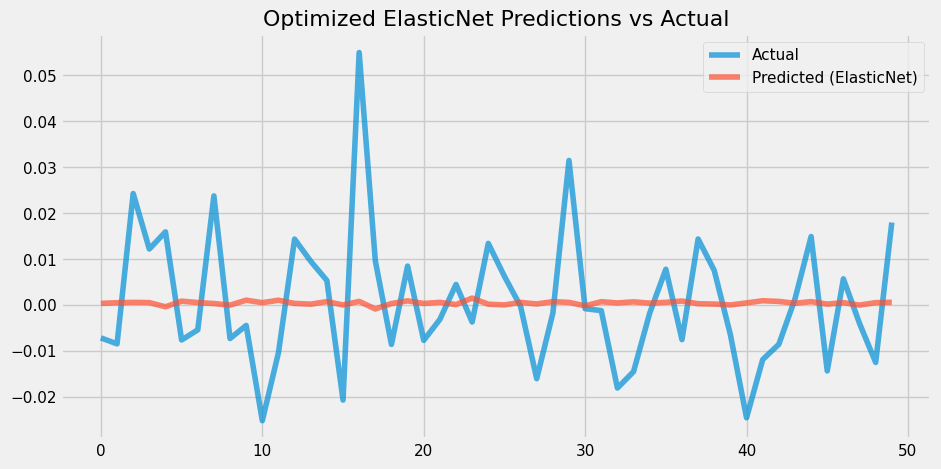

In [14]:
# Get the best model
best_model = grid_search.best_estimator_

# Predict on Test Set
y_pred_best = best_model.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred_best)

print(f"Final Optimized ElasticNet MSE: {final_mse:.8f}")

# Visualization check
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual', alpha=0.7)
plt.plot(y_pred_best[:50], label='Predicted (ElasticNet)', alpha=0.7)
plt.legend()
plt.title("Optimized ElasticNet Predictions vs Actual")
plt.show()

### [Mastering Classification in Trading with Logistic Regression](https://medium.com/@simplifiedzone/mastering-classification-in-trading-with-logistic-regression-9dd12a05fb70)

> Machine Learning for Quants (Part 3)

#### **Data Setup and Binary Target**

In [15]:
# 1. Fetch Data
df = yf.download('SPY', start='2010-01-01', end='2026-01-01', multi_level_index=False, progress=False, interval='1d')
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

# 2. Create Binary Target
# If Return > 0, Class is 1 (Up). Otherwise 0 (Down).
df['Direction'] = np.where(df['Return'] > 0, 1, 0)

# 3. Create Lagged Features (Lags 1-5)
lags = 5
feature_cols = []
for i in range(1, lags + 1):
    col_name = f'Lag_{i}'
    df[col_name] = df['Return'].shift(i)
    feature_cols.append(col_name)

df.dropna(inplace=True)
display(df.sample(10))

# Define X (Features) and y (Target)
X = df[feature_cols]
y = df['Direction']  # Note: Target is now 'Direction', not 'Return'

print("Class Distribution:")
display(y.value_counts(normalize=True))

,Close,High,Low,Open,Volume,Return,Direction,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
Date,,,,,,,,,,,,
2021-03-24,361.9371,366.8218,361.8904,365.1874,97588600,-0.0051,0,-0.0079,0.0080,-0.0019,-0.0145,0.0034
2025-07-11,618.3748,619.6044,616.3024,617.5022,63670200,-0.0035,0,0.0028,0.0060,-0.0005,-0.0075,0.0079
2024-04-30,490.0536,497.4535,490.0536,496.4772,77483600,-0.0158,0,0.0035,0.0095,-0.0038,-0.0005,0.0119
2022-12-01,388.7486,391.2488,386.2389,390.0750,76398200,-0.0007,0,0.0315,-0.0017,-0.0160,-0.0002,0.0063
2011-07-27,100.5655,102.1286,100.4346,102.0978,249020100,-0.0205,0,-0.0037,-0.0056,0.0007,0.0139,-0.0006
2012-03-23,109.2528,109.3779,108.3922,108.9946,120521000,0.0032,1,-0.0072,-0.0016,-0.0029,0.0039,0.0014
2020-07-17,297.0398,297.8246,295.2117,297.1876,62774900,0.0029,1,-0.0033,0.0092,0.0130,-0.0087,0.0102
2013-02-11,120.8380,120.9415,120.5355,120.8141,73775000,-0.0002,0,0.0056,-0.0013,0.0007,0.0101,-0.0112
2011-08-12,90.9555,91.7949,90.3087,91.1711,313731600,0.0067,1,0.0449,-0.0442,0.0465,-0.0651,-0.0015


Class Distribution:


,proportion
Direction,
1,0.5535
0,0.4465


#### **Splitting and Scaling**

In [16]:
# 1. Split Data (Chronological)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 2. Initialize Scaler
scaler = StandardScaler()

# 3. Fit on Train, Transform Train
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform Test (Do NOT fit on test!)
X_test_scaled = scaler.transform(X_test)

print("First 5 Scaled Train Rows:\n", X_train_scaled[:5])

First 5 Scaled Train Rows:
 [[ 0.0821  0.2566  0.3387  0.0191  0.1954]
 [-0.8903  0.0815  0.2575  0.3386  0.0189]
 [ 0.7214 -0.8916  0.0822  0.2574  0.3384]
 [ 0.2007  0.7212 -0.8917  0.082   0.2571]
 [-1.0624  0.2001  0.7224 -0.8919  0.0818]]


#### **Training Logistic Regression**

In [17]:
# Initialize and Train
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Predict Classes (0 or 1)
y_pred = log_model.predict(X_test_scaled)

# Predict Probabilities (0.0 to 1.0)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1] # Probability of Class 1

score = log_model.score(X_test_scaled, y_test)
print(f"Accuracy: {score:.4f}")

Accuracy: 0.5634


#### **The Confusion Matrix**

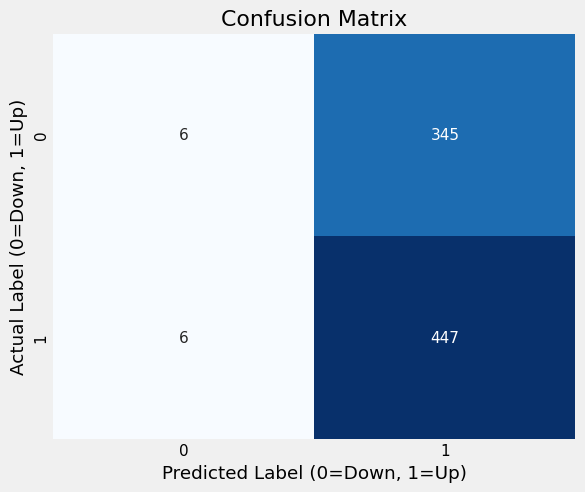

Model Accuracy: 0.5634


In [18]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label (0=Down, 1=Up)')
plt.ylabel('Actual Label (0=Down, 1=Up)')
plt.title('Confusion Matrix')
plt.show()

# Simple Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.4f}")

#### **Advanced Metrics (Precision & Recall)**

              precision    recall  f1-score   support

           0       0.50      0.02      0.03       351
           1       0.56      0.99      0.72       453

    accuracy                           0.56       804
   macro avg       0.53      0.50      0.38       804
weighted avg       0.54      0.56      0.42       804




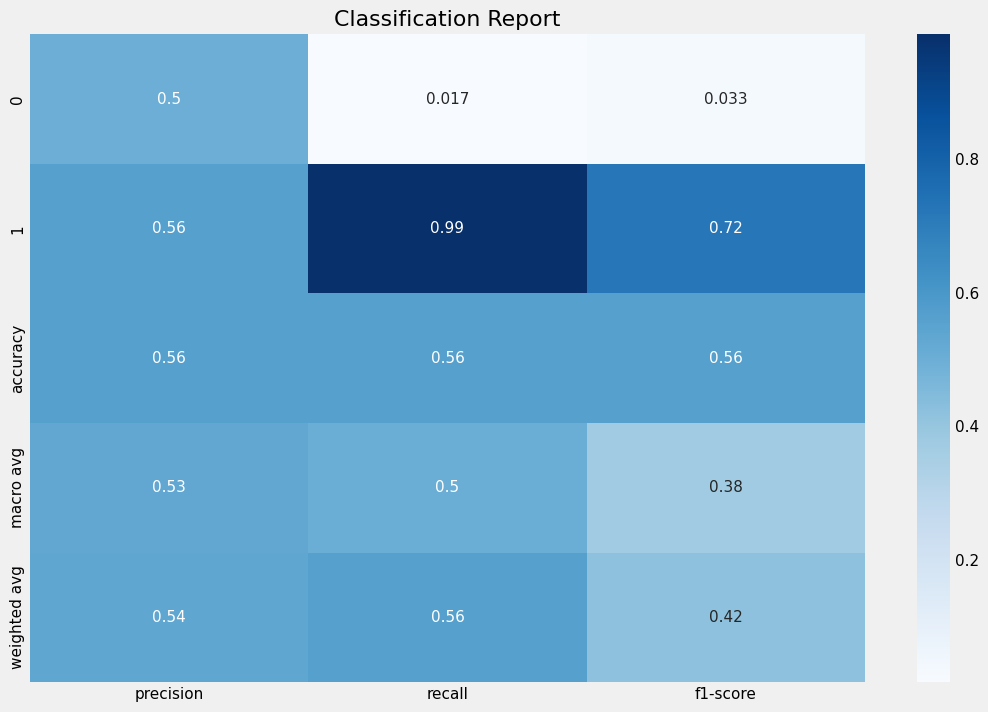

In [19]:
print(classification_report(y_test, y_pred)); print()
plot_classification_report(y_test, y_pred, y_prob)

#### **The Receiver Operating Characteristic (ROC) Curve**

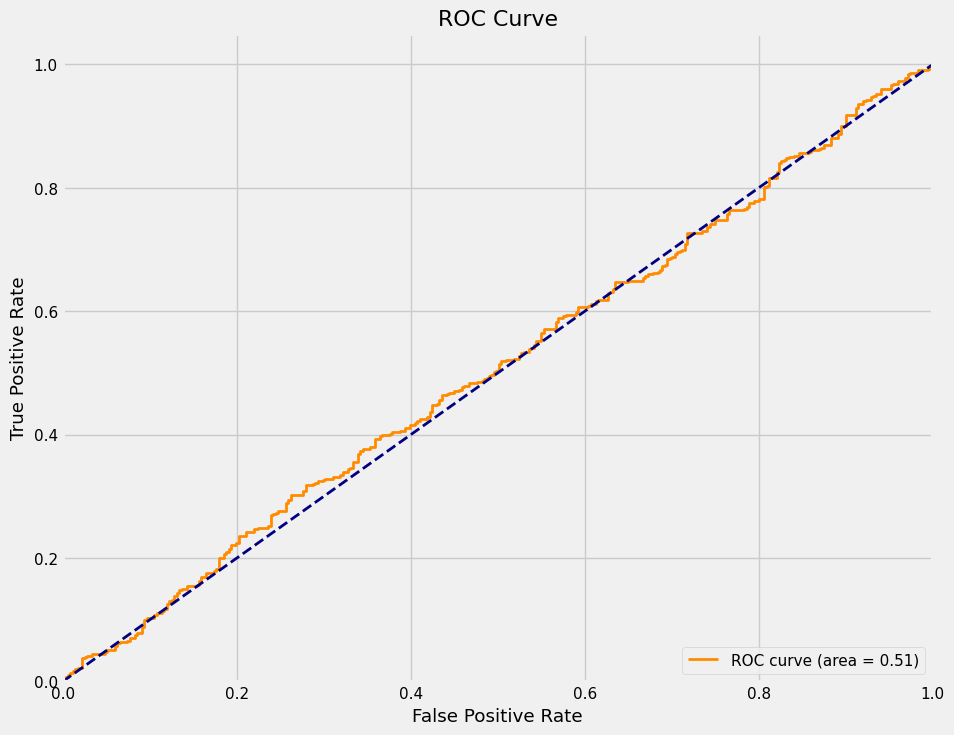

In [20]:
# Calculate rates
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random Guess Line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

### [Credit Risk with Machine Learning for Quants](https://wire.insiderfinance.io/mastering-credit-risk-with-machine-learning-for-quants-371777b3ebad)

> Machine Learning for Quants (Part 4)

#### **Generating the Dataset**

In [21]:
# 1. Generate Synthetic Data
# We create 10,000 samples, 4 features.
# weights=[0.95, 0.05] creates an imbalance (5% defaults)
X, y = make_classification(n_samples=10000, n_features=4, n_informative=3,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.95, 0.05], random_state=42)

# 2. Convert to DataFrame for readability
columns = ['Income', 'Loan_Amount', 'Age_Normalized', 'Credit_Score_Normalized']
df = pd.DataFrame(X, columns=columns)
df['Default'] = y

# 3. Inspect the Imbalance
print("Class Distribution:")
display(df['Default'].value_counts(normalize=True))

print("\nFirst 5 rows:")
display(df.head())

Class Distribution:


,proportion
Default,
0,0.9454
1,0.0546



First 5 rows:


,Income,Loan_Amount,Age_Normalized,Credit_Score_Normalized,Default
0,-0.7863,0.9211,-0.9557,-0.9759,0
1,-0.7385,0.9465,-0.6788,-1.0642,0
2,-2.9367,1.3290,-2.6383,-0.8626,0
3,-2.2418,1.3737,-1.8764,0.5455,0
4,-1.2452,0.7898,-1.6470,0.6667,0


#### **Preprocessing (Split & Scale)**

In [22]:
# Define Features and Target
X = df.drop('Default', axis=1)
y = df['Default']

# 1. Random Split (Shuffle=True is default, but good to be explicit)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 2. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 4)
Test set: (2000, 4)


#### **Baseline Logistic Regression**

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1894
           1       0.99      0.73      0.84       106

    accuracy                           0.98      2000
   macro avg       0.99      0.86      0.91      2000
weighted avg       0.99      0.98      0.98      2000

Baseline AUC Score: 0.9375


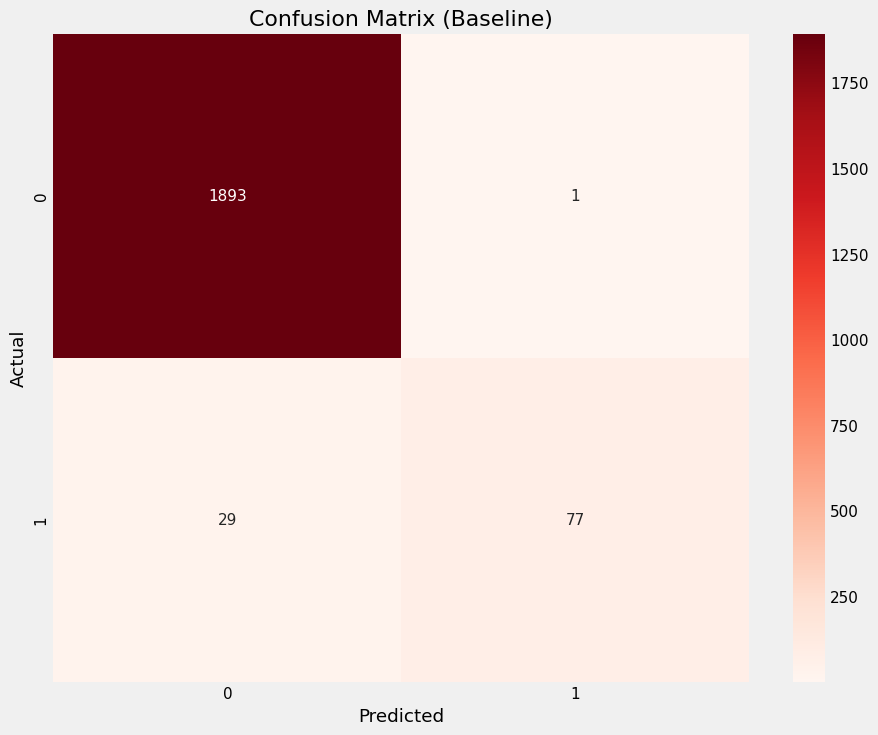

In [23]:
# Initialize Model (Standard)
model_base = LogisticRegression()
model_base.fit(X_train_scaled, y_train)

# Predict
y_pred = model_base.predict(X_test_scaled)
y_prob = model_base.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred))

print(f"Baseline AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Visualizing the Imbalance in Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### **Adding Complexity (Polynomial Features)**

In [24]:
# 1. Create Polynomial Features (Degree 2)
# This creates interaction terms: Income^2, Income*Age, Age^2, etc.
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"New Feature Count: {X_train_poly.shape[1]} (Original was 4)")

# 2. Train New Model on Complex Data
# We use 'class_weight=balanced' to help the model pay attention to rare defaults
model_poly = LogisticRegression(class_weight='balanced', solver='liblinear')
model_poly.fit(X_train_poly, y_train)

# Predict
y_prob_poly = model_poly.predict_proba(X_test_poly)[:, 1]

print(f"Polynomial Model AUC Score: {roc_auc_score(y_test, y_prob_poly):.4f}")

New Feature Count: 14 (Original was 4)
Polynomial Model AUC Score: 0.9607


#### **Comparing Performance (ROC Curves)**

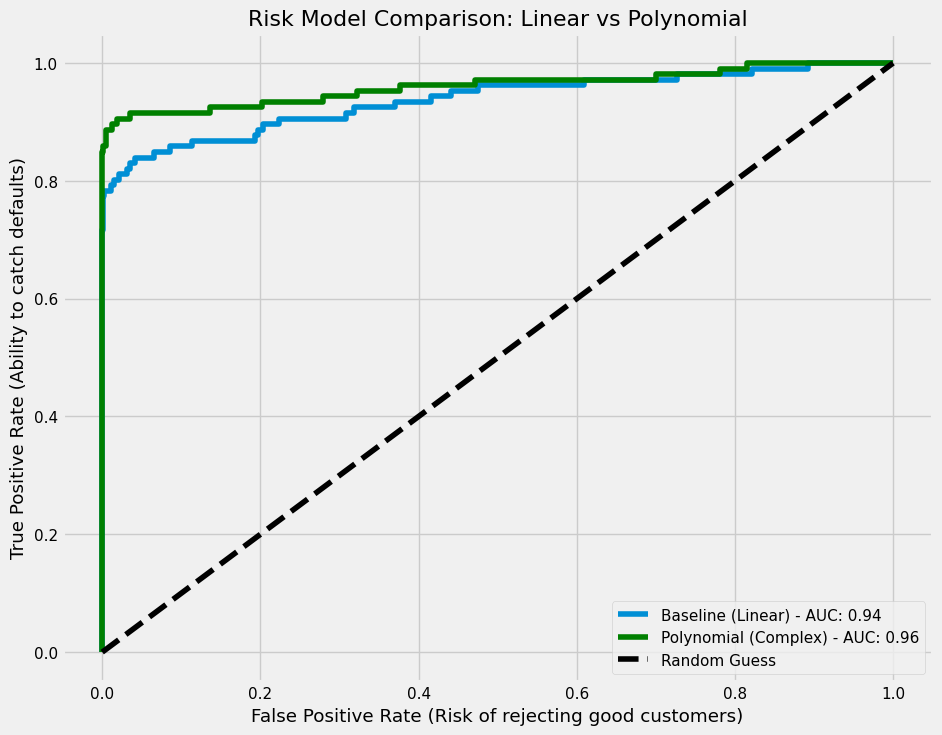

In [25]:
# Calculate ROC for Baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob)

# Calculate ROC for Polynomial
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_prob_poly)

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr_base, tpr_base, label=f'Baseline (Linear) - AUC: {roc_auc_score(y_test, y_prob):.2f}')
plt.plot(fpr_poly, tpr_poly, label=f'Polynomial (Complex) - AUC: {roc_auc_score(y_test, y_prob_poly):.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate (Risk of rejecting good customers)')
plt.ylabel('True Positive Rate (Ability to catch defaults)')
plt.title('Risk Model Comparison: Linear vs Polynomial')
plt.legend()
plt.show()

#### [Boosting Algorithms for Finance with Python: AdaBoost & Gradient](https://medium.com/@simplifiedzone/990d957bb7ea)

> Machine Learning for Quants (Part 10)

In [26]:
# Simulate Credit Card Default Data
# Defaults are often imbalanced; we set weights to 80% non-default, 20% default
X, y = make_classification(n_samples=3000, n_features=15, n_informative=10,
                           weights=[0.8, 0.2], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Target Distribution in Train: {np.bincount(y_train)}")

Target Distribution in Train: [1798  452]


--- AdaBoost Performance ---
AdaBoost AUC: 0.9011
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       595
           1       0.80      0.54      0.65       155

    accuracy                           0.88       750
   macro avg       0.84      0.75      0.79       750
weighted avg       0.87      0.88      0.87       750




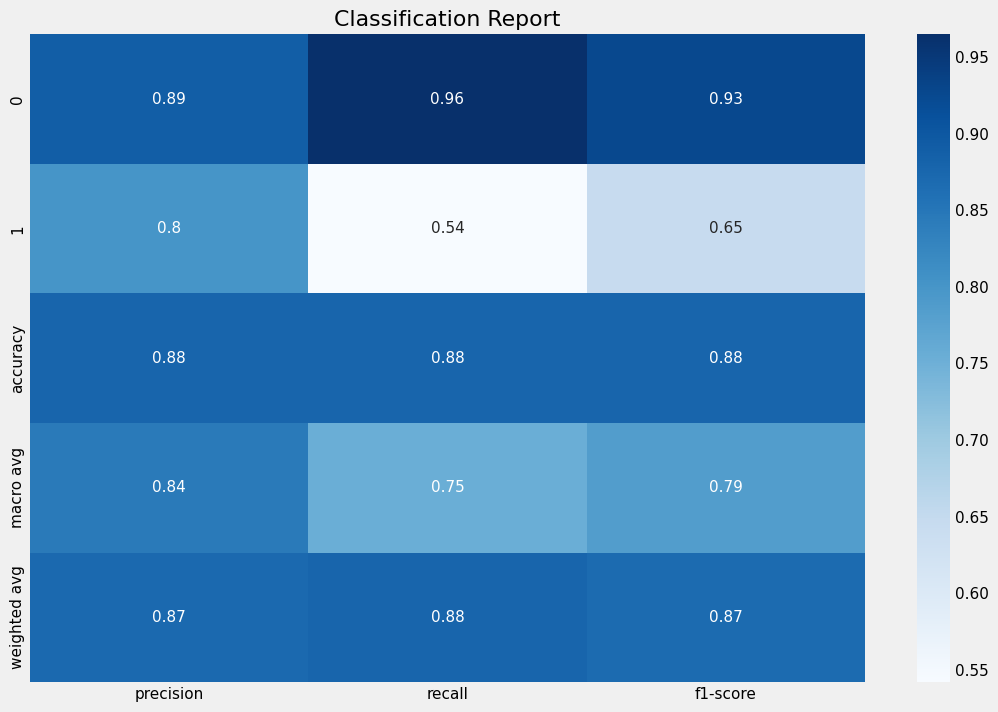

In [27]:
# Initialize AdaBoost
# n_estimators: The maximum number of stumps to build
# learning_rate: Shrinks the contribution of each classifier
ada_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)

# Train the model
ada_model.fit(X_train, y_train)

# Predict and Evaluate
ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:, 1]

print("--- AdaBoost Performance ---")
print(f"AdaBoost AUC: {roc_auc_score(y_test, ada_prob):.4f}")

print(classification_report(y_test, ada_pred)); print()
plot_classification_report(y_test, ada_pred, ada_prob)


--- Gradient Boosting Performance ---
Gradient Boosting AUC: 0.9522
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       595
           1       0.93      0.73      0.82       155

    accuracy                           0.93       750
   macro avg       0.93      0.86      0.89       750
weighted avg       0.93      0.93      0.93       750




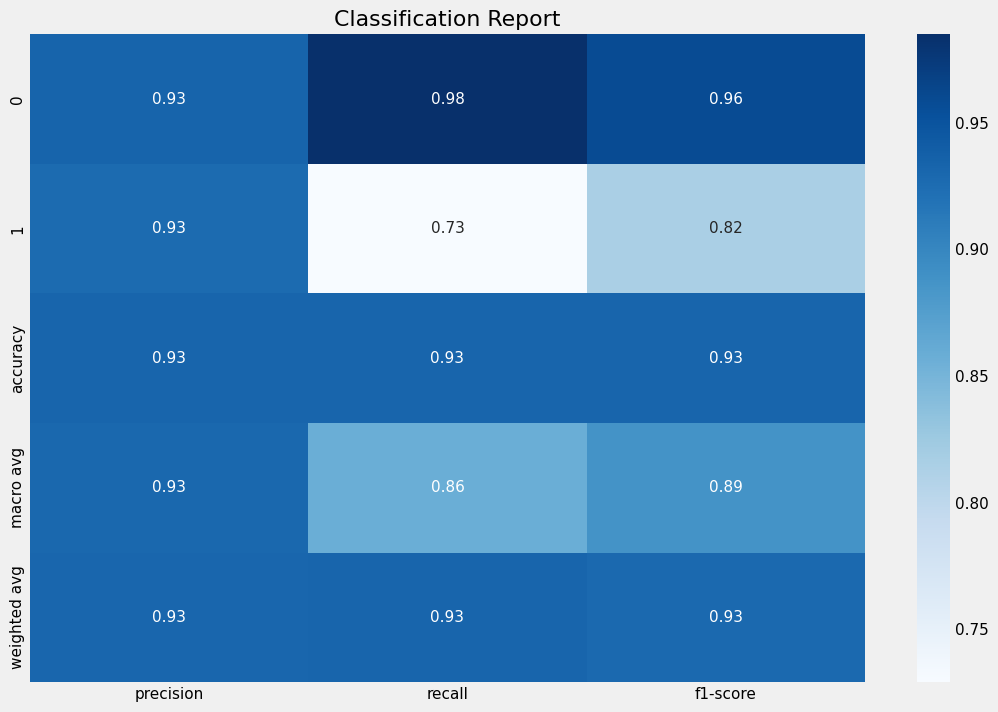

In [28]:
# Initialize Gradient Boosting
# max_depth: GBMs use slightly deeper trees than AdaBoost's stumps
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict and Evaluate
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("\n--- Gradient Boosting Performance ---")
print(f"Gradient Boosting AUC: {roc_auc_score(y_test, gb_prob):.4f}")

print(classification_report(y_test, gb_pred)); print()
plot_classification_report(y_test, gb_pred, gb_prob)

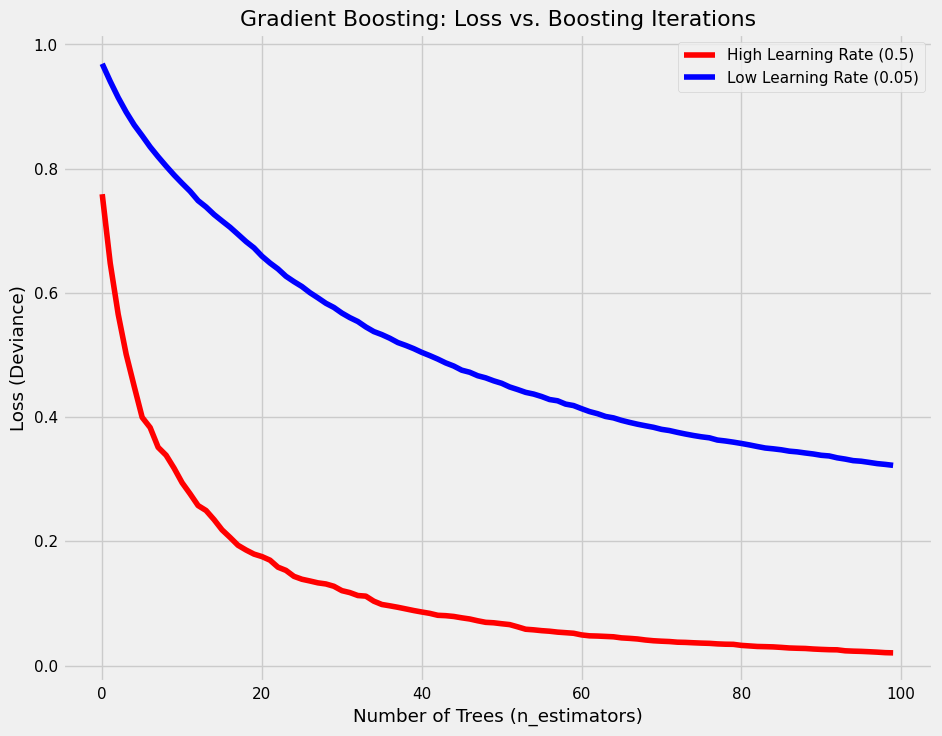

In [29]:
# Demonstrating the trade-off visually by plotting training deviance (loss)
train_errors_high_lr = []
train_errors_low_lr = []

# High LR model (0.5)
gb_high = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
gb_high.fit(X_train, y_train)

# Low LR model (0.05)
gb_low = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
gb_low.fit(X_train, y_train)

# Plotting the loss at each boosting stage
plt.figure(figsize=(10, 8))
plt.plot(gb_high.train_score_, label='High Learning Rate (0.5)', color='red')
plt.plot(gb_low.train_score_, label='Low Learning Rate (0.05)', color='blue')
plt.title("Gradient Boosting: Loss vs. Boosting Iterations")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Loss (Deviance)")
plt.legend()
plt.grid(True)
plt.show()

### **[Support Vector Machines for Financial Predictions](https://medium.com/@simplifiedzone/6d4974c2bebb)**

> Machine Learning for Quants (Part 11)

##### Data Preparation and Feature Scaling

In [30]:
# Simulate Financial Market Data (1500 days, 5 technical indicators)
X, y = make_classification(n_samples=1500, n_features=5, n_informative=3,
                           n_redundant=1, random_state=42, class_sep=0.8)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CRITICAL STEP: Scaling
# SVMs optimize geometric distance. If one indicator ranges from 1-100 and another from 0-0.01,
# the large numbers will dominate the distance calculation mathematically.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Training the Support Vector Classifier (SVC)

Training SVM Model...
--- SVM Performance ---
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       152
           1       0.88      0.93      0.90       148

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300




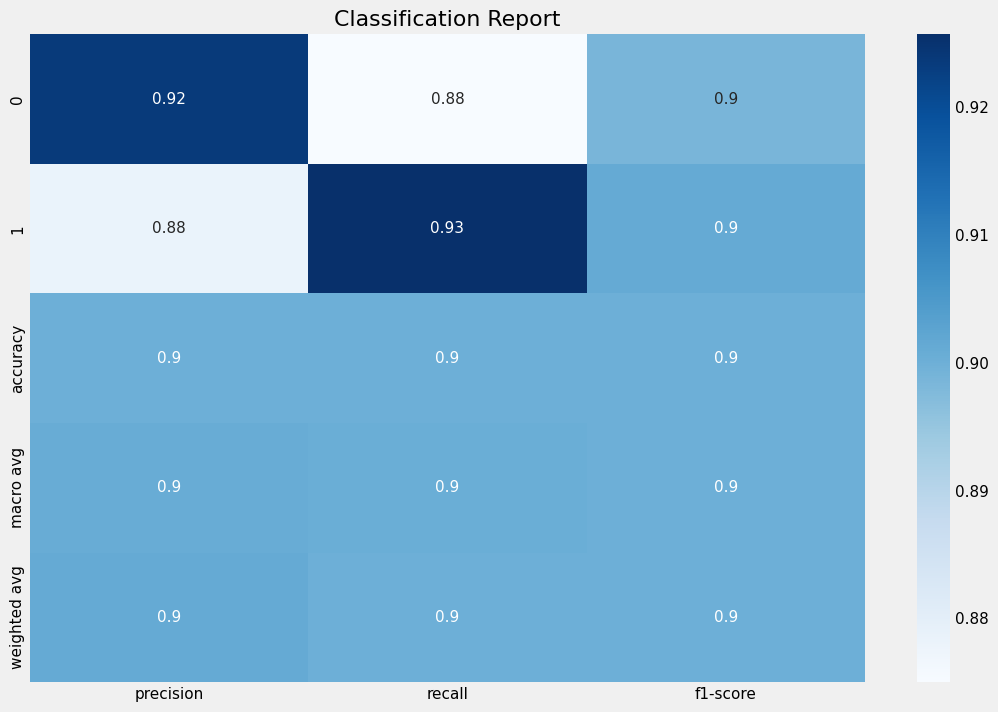

In [31]:
# Initialize the SVM Classifier
# probability=True allows us to plot ROC curves later
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

# Train the model
print("Training SVM Model...")
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred = svm_model.predict(X_test_scaled)

print("--- SVM Performance ---")
print(classification_report(y_test, y_pred)); print()
plot_classification_report(y_test, y_pred, None)

##### Visualizing the ROC Curve

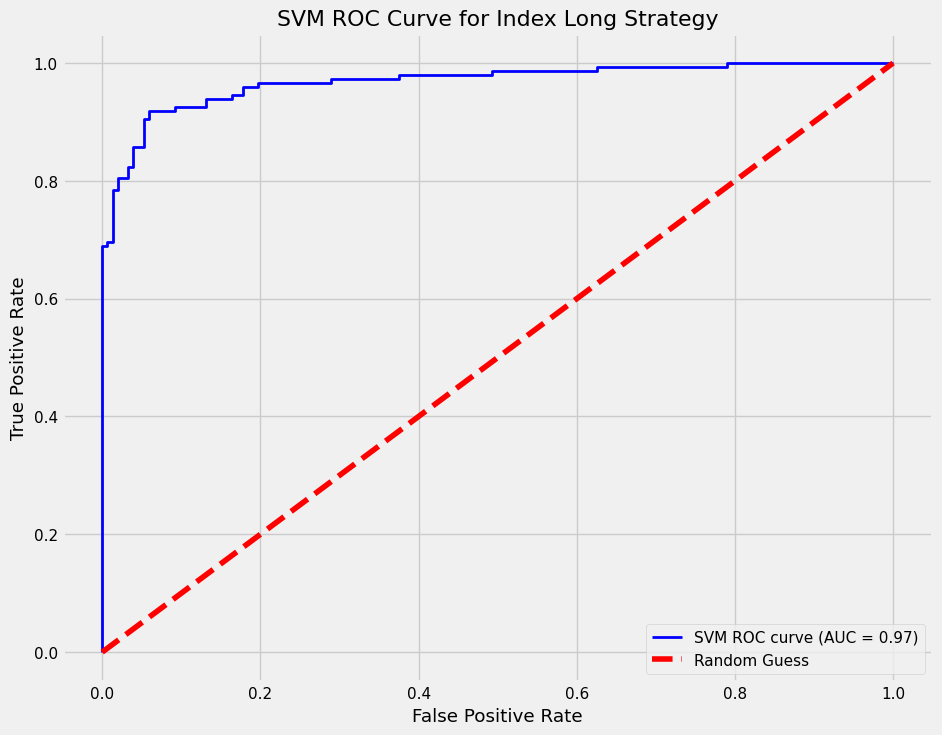

In [32]:
# Get prediction probabilities for Class 1 (Long Position)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'SVM ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve for Index Long Strategy')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### **[Deep Learning with ANNs in Quant Finance](https://medium.com/@simplifiedzone/c0b48c7761d8)**

> Machine Learning for Quants (Part 12)

In [33]:
X = np.random.randn(2000, 8)
# Target y is a complex non-linear combination of the inputs + noise
y = (np.sin(X[:, 0]) + X[:, 1]**2 + np.log(np.abs(X[:, 2])+1) - X[:, 3]*1.5) + np.random.normal(0, 0.5, 2000)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Neural Networks are EXTREMELY sensitive to unscaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Building the Architecture using Keras

In [34]:
# Initialize a Sequential model
model = Sequential()

# Add the first Hidden Layer (requires input_dim matching feature count)
# 64 neurons, ReLU activation
model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))

# Add a second Hidden Layer
# 32 neurons, ReLU activation
model.add(Dense(32, activation='relu'))

# Add the Output Layer
# 1 neuron, Linear activation (default) because we are predicting a continuous numerical value
model.add(Dense(1))

# Review the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

##### Compiling the Model

In [35]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

##### Training the Network (Epochs and Batch Size)

In [36]:
# Train the model
history = model.fit(
  X_train_scaled, y_train,
  epochs=50,
  batch_size=32,
  validation_split=0.2, # Hold out 20% of training data to check for overfitting
  verbose=1             # Set to 1 to see the progress bar
)

print("Training Complete.")

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6878 - mae: 1.6368 - val_loss: 3.9561 - val_mae: 1.4591
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5185 - mae: 1.1615 - val_loss: 2.5129 - val_mae: 1.0942
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6570 - mae: 0.9222 - val_loss: 1.9201 - val_mae: 0.9455
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2327 - mae: 0.8000 - val_loss: 1.4188 - val_mae: 0.8221
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8688 - mae: 0.6784 - val_loss: 0.9989 - val_mae: 0.6945
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6201 - mae: 0.5839 - val_loss: 0.7335 - val_mae: 0.6134
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4956 - mae: 0.5362 - val_loss: 0.6100 - val_mae: 0.5754
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4470 - mae: 0.5170 - val_loss: 0.5612 - val_mae: 0.5598
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4244 - mae: 

##### Visualizing Learning and Evaluating

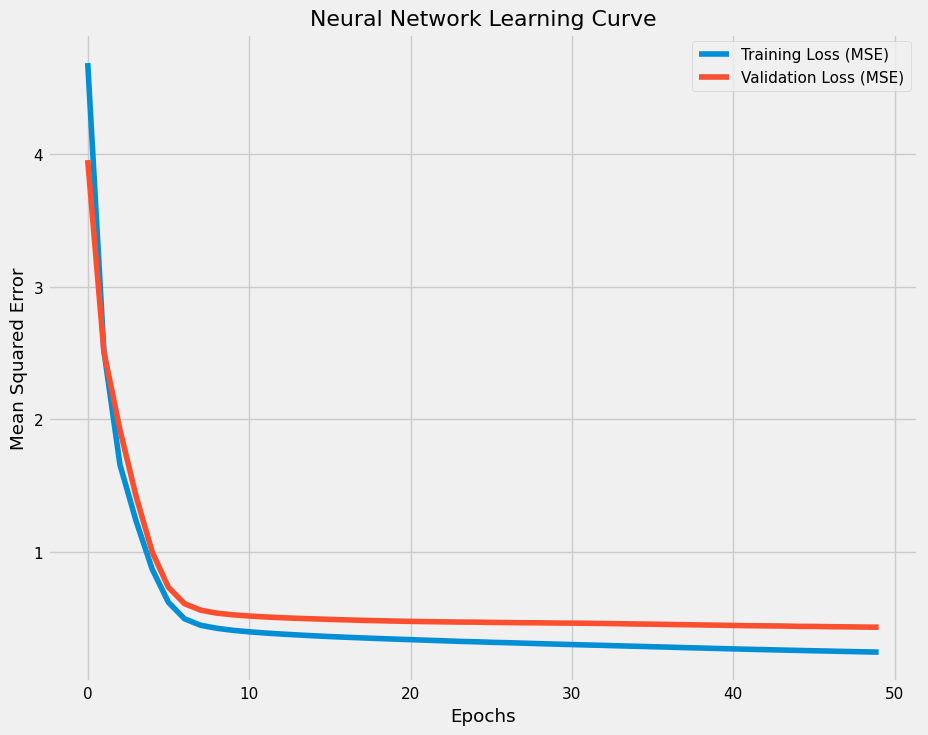

Test Set Final MSE: 0.4186
Test Set Final MAE: 0.5161


In [37]:
# Plot Training vs. Validation Loss
plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Neural Network Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# Final Evaluation on the unseen Test Set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Set Final MSE: {test_loss:.4f}")
print(f"Test Set Final MAE: {test_mae:.4f}")

### **[Gradient Descent and Loss Landscapes to Model Yield Curves and Credit Defaults](https://medium.com/@simplifiedzone/02a67b2d6166)**

> Machine Learning for Quants (Part 13)

In [38]:
# 1. Simulate a complex, non-linear financial dataset
X = np.random.uniform(-5, 5, (1000, 1))
# Target is a sine wave with noise (highly non-convex relationship)
y = np.sin(X) + np.random.normal(0, 0.2, (1000, 1))

# Function to build our standard architecture
def build_model(optimizer):
  model = Sequential([
    Dense(32, activation='relu', input_shape=(1,)),
    Dense(32, activation='relu'),
    Dense(1) # Linear output for regression
  ])
  model.compile(optimizer=optimizer, loss='mse')
  return model

##### Define Optimizers to Compare

In [39]:
# Vanilla SGD (Often slow and gets stuck)
opt_sgd = SGD(learning_rate=0.01)

# SGD with Momentum (Builds up speed in consistent directions)
opt_momentum = SGD(learning_rate=0.01, momentum=0.9)

# Adam (Adaptive Moment Estimation - Industry Standard)
opt_adam = Adam(learning_rate=0.01)

##### Train the Models

In [40]:
epochs = 100
batch_size = 32 # Using Mini-Batch approach

In [41]:
print("Training Vanilla SGD...")
history_sgd = build_model(opt_sgd).fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

Training Vanilla SGD...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6150  
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5116 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4692 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4306 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3941 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3587 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3233 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2877 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2526 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2187 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1870 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1585 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1340 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1138 
Epoch 15/100
32/32 ━━━━━━━━━━━━━

In [42]:
print("Training SGD with Momentum...")
history_momentum = build_model(opt_momentum).fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

Training SGD with Momentum...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5261
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2671
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0843
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0573
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0543 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0542 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0541 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0540 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0538 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0537 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0535 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0534
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0533 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0532 
Epoch 15/100
32/32 ━━━━━━━━━━━━━

In [43]:
print("Training Adam...")
history_adam = build_model(opt_adam).fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1)

Training Adam...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3862   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0676 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0561
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0567
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0565
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0566
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0561
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0558
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0556
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0552
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0539
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0536
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0533
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0529
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

##### Plot the Loss Convergence

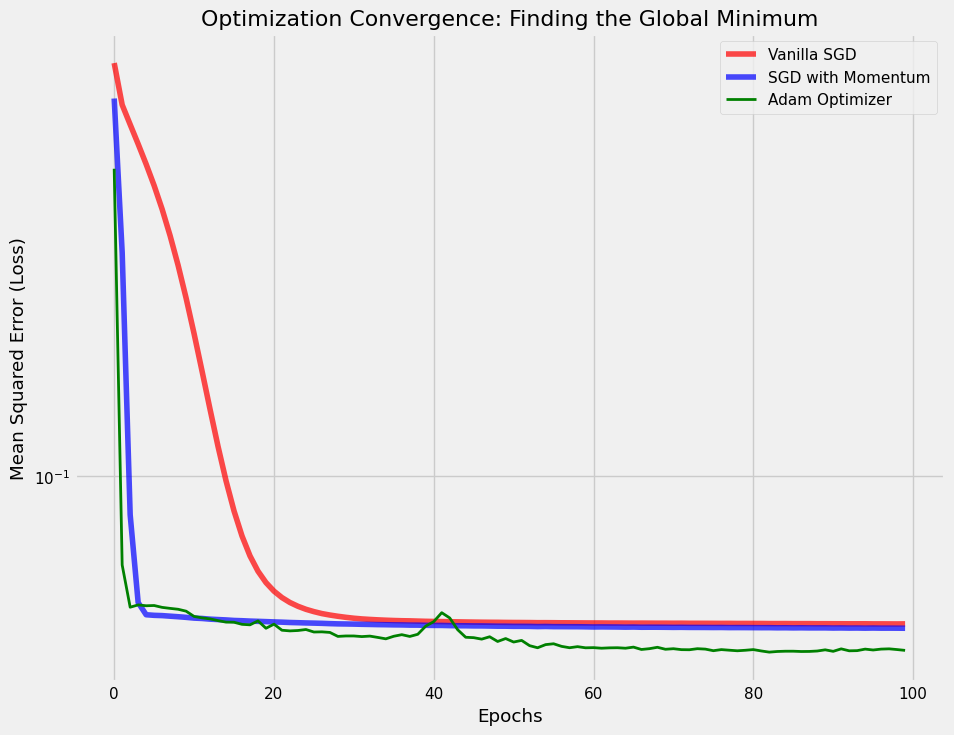

In [44]:
plt.figure(figsize=(10, 8))
plt.plot(history_sgd.history['loss'], label='Vanilla SGD', color='red', alpha=0.7)
plt.plot(history_momentum.history['loss'], label='SGD with Momentum', color='blue', alpha=0.7)
plt.plot(history_adam.history['loss'], label='Adam Optimizer', color='green', linewidth=2)
plt.title('Optimization Convergence: Finding the Global Minimum')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.yscale('log') # Log scale helps visualize the rapid drop
plt.grid(True)
plt.show()

#### **[Ensemble Learning for Finance: Bagging and Stacking](https://medium.com/@simplifiedzone/51b95c9d5667)**

> Machine Learning for Quants (Part 9)

##### Simulating an Index Classification Problem

In [45]:
# 1. Simulate Financial Index Data
# 2000 days of data, 10 technical indicators (features)
X, y = make_classification(n_samples=2000, n_features=10, n_informative=7,
                           n_redundant=2, random_state=42, weights=[0.5, 0.5])

# Scale the data (Crucial for SVM and regularized models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training (80%) and Holdout/Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (1600, 10)
Testing features shape: (400, 10)


##### Evaluating Base Learners Independently

In [46]:
# Initialize Base Learners
# Note: probability=True is required for SVM if we want to extract predicted probabilities later
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_svm = SVC(probability=True, random_state=42)
model_nb = GaussianNB()

base_models = [('Decision Tree', model_dt),
              ('SVM', model_svm),
              ('Naive Bayes', model_nb)]

# Train and evaluate each independently
print("--- Base Learner Independent Performance ---")
for name, model in base_models:
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"{name} Accuracy: {acc:.4f}")

--- Base Learner Independent Performance ---
Decision Tree Accuracy: 0.8475
SVM Accuracy: 0.9350
Naive Bayes Accuracy: 0.7850


##### Implementing Stacking Classifier

In [47]:
# Define the Level-0 estimators (Base Models)
estimators = [
  ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
  ('svm', SVC(probability=True, random_state=42)),
  ('nb', GaussianNB())
]

# Define the Level-1 meta-model
# Logistic Regression is ideal as it acts as a weighted voter
meta_model = LogisticRegression()

# Initialize the Stacking Classifier
# cv=5 means it uses 5-fold cross-validation to generate the training data for the meta-model
stacking_clf = StackingClassifier(
  estimators=estimators,
  final_estimator=meta_model,
  cv=5
)

# Train the Stacking ensemble
print("\n--- Training Stacking Ensemble ---")
stacking_clf.fit(X_train, y_train)

# Evaluate the ensemble
stack_pred = stacking_clf.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)
print(f"Stacking Ensemble Accuracy: {stack_acc:.4f}")


--- Training Stacking Ensemble ---
Stacking Ensemble Accuracy: 0.9400


##### Inspecting the Meta-Model

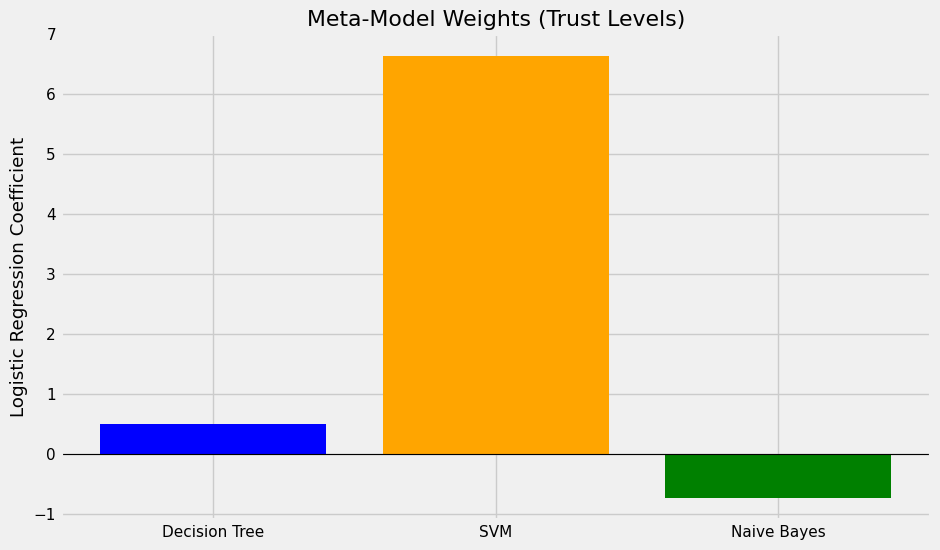

In [48]:
# Extract the trained meta-model
meta_model_trained = stacking_clf.final_estimator_

# The coefficients represent the "weight" given to each base learner
weights = meta_model_trained.coef_[0]

plt.figure(figsize=(10, 6))
plt.bar(['Decision Tree', 'SVM', 'Naive Bayes'], weights, color=['blue', 'orange', 'green'])
plt.title("Meta-Model Weights (Trust Levels)")
plt.ylabel("Logistic Regression Coefficient")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

#### **[Hyperparameter Tuning for ML Quant Models](https://medium.com/@simplifiedzone/487a093c529e)**

> Machine Learning for Quants (Part 14)

In [49]:
# 1. Simulate Financial Signal Data
X, y = make_classification(n_samples=2000, n_features=10, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
# 2. Define the Hyperparameter Space
param_grid = {
  'n_estimators': [50, 100, 200],
  'max_depth': [None, 5, 10, 15],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4]
}

# Base Model
rf = RandomForestClassifier(random_state=42)

In [51]:
# --- GRID SEARCH ---
print("Starting Grid Search...")
start_time = time.time()

# cv=5 means 5-fold cross validation. n_jobs=-1 uses all CPU cores.
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"Grid Search Time: {grid_time:.2f} seconds")
print(f"Best Grid Parameters: {grid_search.best_params_}")

Starting Grid Search...
Grid Search Time: 244.75 seconds
Best Grid Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [52]:
# --- RANDOM SEARCH ---
print("\nStarting Random Search...")
start_time = time.time()
# n_iter=20 means we only test 20 random combinations out of the possible 108.
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                                   n_iter=20, cv=5, n_jobs=-1, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print(f"Random Search Time: {random_time:.2f} seconds")
print(f"Best Random Parameters: {random_search.best_params_}")


Starting Random Search...
Random Search Time: 47.78 seconds
Best Random Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}



--- Final Model Performance on Unseen Test Set ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       185
           1       0.93      0.90      0.92       215

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400




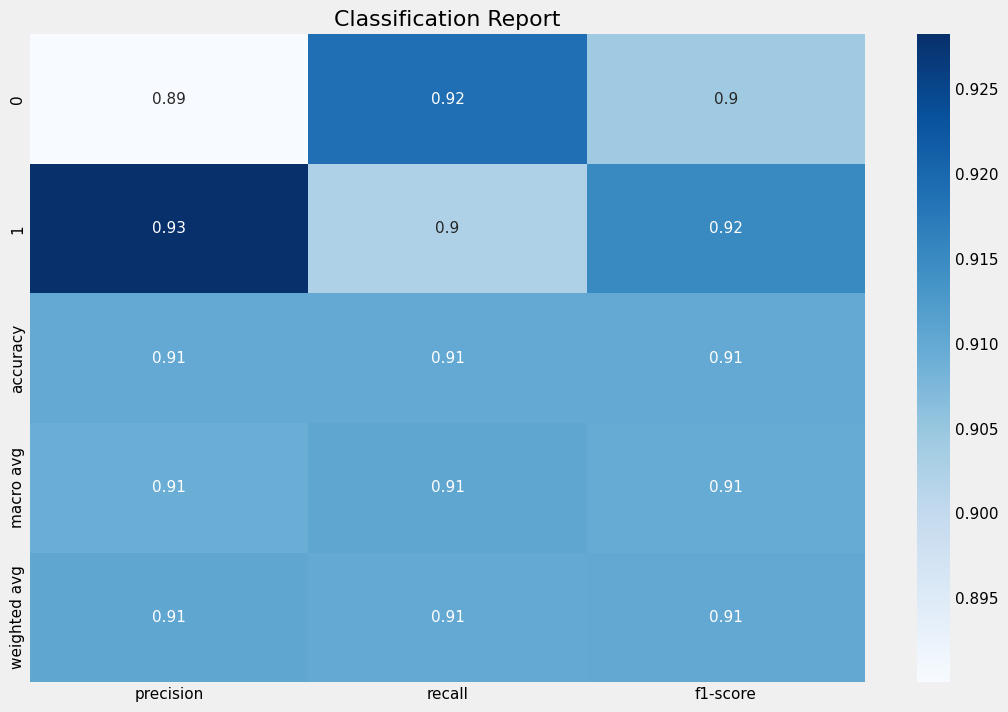

In [53]:
# 3. Evaluate the Best Model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Final Model Performance on Unseen Test Set ---")
print(classification_report(y_test, y_pred)); print()
plot_classification_report(y_test, y_pred, None)

#### **[Machine Learning for Accurate Credit Risk Prediction](https://medium.com/@simplifiedzone/222deff73e80)**

> Machine Learning for Quants (Part 15)

> Credit Risk Modeling, Class Imbalance

In [54]:
# 1. Simulate Highly Imbalanced Credit Data (10,000 samples)
# 98% Good Loans (0), 2% Defaults (1)
X, y = make_classification(n_samples=10000, n_features=10, n_informative=5,
                           weights=[0.98, 0.02], random_state=42)

# 2. Split Data Chronologically/Randomly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original Training Defaults: {sum(y_train == 1)} out of {len(y_train)}")

Original Training Defaults: 198 out of 8000


In [55]:
# 3. Apply SMOTE strictly to the Training Data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE Training Defaults: {sum(y_train_smote == 1)} out of {len(y_train_smote)}")

# 4. Scale the Data (Fit on SMOTE train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test) # Transform real test data

SMOTE Training Defaults: 7802 out of 15604


In [56]:
# 5. Build the Neural Network Classifier
model = Sequential([
  Dense(32, activation='relu', input_shape=(10,)),
  Dense(16, activation='relu'),
  Dense(1, activation='sigmoid') # Sigmoid forces output between 0 and 1 (Probability)
])

# Use Binary Crossentropy for binary classification
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network on SMOTE data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Credit Default Prediction Performance ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1952
           1       0.27      0.69      0.39        48

    accuracy                           0.95      2000
   macro avg       0.63      0.82      0.68      2000
weighted avg       0.97      0.95      0.96      2000




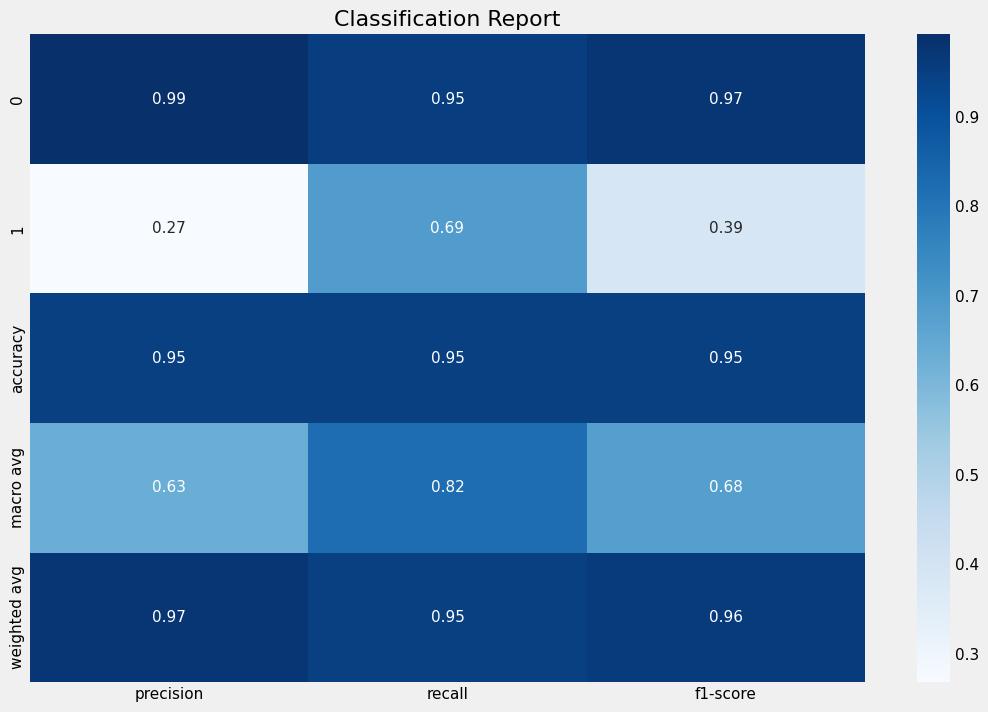

In [57]:
# 6. Train the Model on the SMOTE balanced data
print("\nTraining Neural Network on SMOTE data...")
model.fit(X_train_scaled, y_train_smote, epochs=20, batch_size=64, verbose=0)

# 7. Evaluate on the REAL, Imbalanced Test Data
y_pred_prob = model.predict(X_test_scaled)
# Convert probabilities to hard classes (Threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n--- Credit Default Prediction Performance ---")
print(classification_report(y_test, y_pred)); print()
plot_classification_report(y_test, y_pred, y_pred_prob)

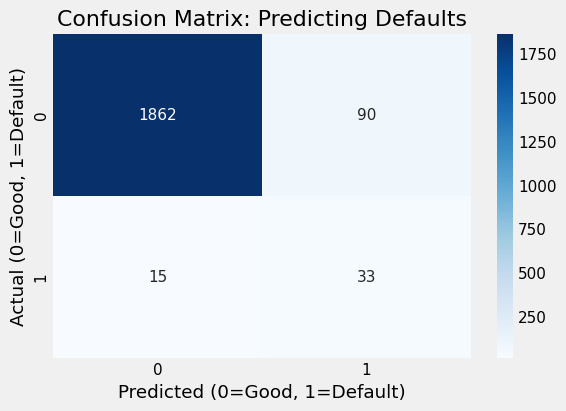

In [58]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicting Defaults')
plt.xlabel('Predicted (0=Good, 1=Default)')
plt.ylabel('Actual (0=Good, 1=Default)')
plt.show()